<a href="https://colab.research.google.com/github/Tefera22/rhine-river-lstm-forecasting/blob/main/notebooks/rhine_lstm_streamflow_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git config --global user.name "Tefera22"
!git config --global user.email "tefixbrhan@gmail.com"

In [ ]:
# Commented out IPython magic to ensure Python compatibility.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
from pandas import DataFrame , concat
from sklearn.metrics import mean_absolute_error , mean_squared_error
# %matplotlib inline
# %config InlineBackend.figure_format = 'retina'
from numpy import mean , concatenate
from math import sqrt
from pandas import read_csv
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM,Activation
from numpy import array , hstack
from tensorflow import keras
import tensorflow as tf

In [ ]:
import pandas as pd
import numpy as np
from pandas import to_datetime

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# define a custom date parser function
def date_parser(data):
    return pd.datetime.strptime(data, '%m/%d/%Y')

# read the CSV file and parse the 'date_column' using the custom parser
df = pd.read_csv('/content/drive/MyDrive/Lobith_Q/Lobith_KNMI.csv',parse_dates=['Date'], date_parser=date_parser)
# Subset data for date range between '1979-01-01' and '2021-06-21'
df = df[df['Date'].between(pd.Timestamp('1980-01-01'), pd.Timestamp('2018-12-31'))].reset_index(drop=True)
df

In [ ]:
import pandas as pd

# Assuming 'Date' is in datetime format, if not, convert it to datetime using:
df['Date'] = pd.to_datetime(df['Date'])

# Set 'Date' column as the DataFrame index
df.set_index('Date', inplace=True)

# # Resample to monthly and annual averages
df_monthly = df.resample('M').mean()  # 'M' represents monthly
df_annual = df.resample('Y').mean()  # 'Y' represents annual

# # Save the monthly and annual average DataFrames to CSV files
# df_monthly.to_csv('monthly_average_data.csv')
# df_annual.to_csv('annual_average_data.csv')

In [ ]:
df

In [ ]:
# Assuming df is your DataFrame
df['Date'] = pd.to_datetime(df['Date'])  # Convert 'datetime' column to datetime format if needed
# Convert the 'Date' column to datetime index
df.set_index('Date', inplace=True)

In [ ]:
# Copy the dates in a new DataFrame, in case you need them later
dates = pd.DataFrame(columns=['Dates'])
dates['Dates'] = df.index.date

In [ ]:
"""**Step(3):-Split the data set into Training and Test**"""

## Split the data sets
from sklearn.model_selection import train_test_split
col = df.columns.to_list()
#Y = df[col[0]].to_numpy()
X = df.to_numpy()
df_train, df_test = train_test_split(X, test_size=0.1, shuffle=False)

In [ ]:
"""**Step(4):-Normalize the data sets**"""

from sklearn.preprocessing import MinMaxScaler
# Create an instance of MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
# extract the Y from the test set, because we will need them to invert the normalization later on
# create the scaler only for the Y in training
qobs = df_train[:,0]
qobs = np.reshape(qobs,[-1,1])
scaler_pred = MinMaxScaler(feature_range=(0, 1))
# Normalize the training inputs
q = scaler_pred.fit_transform(qobs)

# Normalize the training inputs
df_train = scaler.fit_transform(df_train)
# normalize the testing inputs
df_test = scaler.transform(df_test)

In [ ]:
q

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Create an instance of MinMaxScaler for the target variable (Y)
scaler_pred = MinMaxScaler(feature_range=(0, 1))

# Extract the target variable (Y) from the training set
qobs = df_train[:, 0]
qobs = np.reshape(qobs, [-1, 1])

# Normalize the target variable (Y) using the scaler for prediction
q = scaler_pred.fit_transform(qobs)

# Create an instance of MinMaxScaler for the input features
scaler = MinMaxScaler(feature_range=(0, 1))

# Normalize the training inputs
df_train = scaler.fit_transform(df_train)

# Normalize the testing inputs using the same scaler as the training data
df_test = scaler.transform(df_test)
qobs

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Create an instance of MinMaxScaler for the input features
scaler_pred = MinMaxScaler(feature_range=(0, 1))

# Normalize the training and testing inputs
df_train = scaler_pred.fit_transform(df_train)
df_test = scaler_pred.transform(df_test)

# Normalize the target variable in the training set
q = df_train[:, 0]  # Assuming the target variable is in the first column

# Continue with the rest of your code


In [ ]:
q

In [ ]:
"""**Step(5):-Data Preparation for LSTM input(sequence of inputs and labels(prediction)**"""

# Define the number of input and output time steps
window_size = 365  ##  we can change the desired window size here
n_steps_out = 1
# Define the lead time
lead_time = 20  # We can change here the desired lead time for prediction
def prepare_data(df, window_size, lead_time):
    X = []      # input features
    Y = []      # output labels (predictions)
    idx_X = []  # index of X
    idx_y = []  # index of y
    for i in range(0, len(df) - window_size - lead_time):
        X.append(df.iloc[i:i+window_size])
        Y.append(df.iloc[i+window_size+lead_time])
        idx_X.append(df.index[i:i+window_size])
        idx_y.append(df.index[i+window_size+lead_time])
    X = np.array(X)
    Y = np.array(Y)
    idx_X = np.array(idx_X)
    idx_y = np.array(idx_y)
    return X, Y, idx_X, idx_y

In [ ]:

# trasnform df_train into dataframe and get the labels
df_train = pd.DataFrame(df_train)
X_train, y_train, idx_X_train, idx_y_train = prepare_data(df_train, window_size, lead_time)

# trasnform df_test into dataframe and get the labels
df_test = pd.DataFrame(df_test)
X_test, y_test, idx_X_test, idx_y_test= prepare_data(df_test, window_size, lead_time)


In [ ]:

"""**Step(6):-Built Stacked LSTM Model**"""

import tensorflow as tf
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, Activation

# Define function to build and compile LSTM model
def build_model():
    model = Sequential()
    model.add(LSTM(64, activation='relu', return_sequences=True, input_shape=(window_size,1)))
    model.add(LSTM(50, activation='relu', return_sequences=False))
    model.add(Dense(n_steps_out,activation='linear'))
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
    return model


In [ ]:
"""**Step(7):-Training The model**"""

# Create the model object
model = build_model()

# Fit the model
history = model.fit(X_train,y_train, epochs=500, batch_size=32, validation_split=0.3, shuffle=False, callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', verbose=2, patience=20, mode='min')])


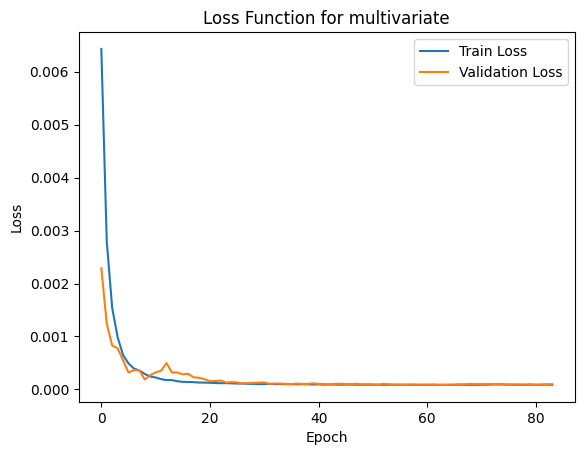

In [ ]:
"""**Step(8):-Plotting Loss Function**"""
import matplotlib.pyplot as plt
# Plot the loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Function for multivariate')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:

"""**Step(9):-Prediction  using the model**"""

prediction = model.predict(X_test)
# CB: de-normalize the prediction. Because the intiial dataset has 6 inputs to normalize
# and the output is only one, you need to create a new scaler, only for the Lobith columns
# I created it in lines 109-111

# invert normalization
uns_prediction = scaler_pred.inverse_transform(prediction)
y_obs = scaler_pred.inverse_transform(np.reshape(y_test,[-1,1]))

36/36 [==============================] - 4s 96ms/step


In [ ]:
y_obs

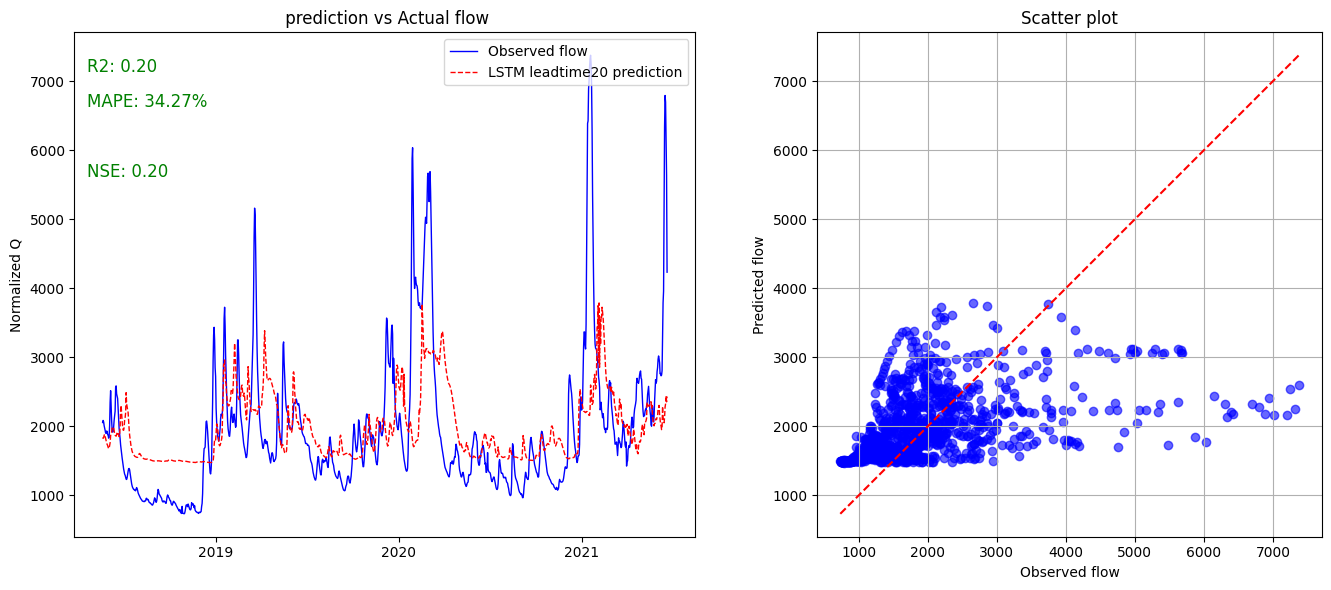

In [ ]:

"""**Step(11):-Visualization of the UNSCALED predicted in comparision of the Observed value**"""
# import necessary libraries
import matplotlib.dates as mdates

from sklearn.metrics import r2_score
from sklearn.metrics import r2_score, mean_squared_error

# get the dates of the testing Y
dates_test = dates.iloc[-len(y_test):]
dates_test = dates_test['Dates'].to_list()

import matplotlib.dates as mdates

# create a dataframe with the data to plot and the dates
dr = pd.DataFrame(columns=['Dates','y_obs','y_pred'])
dr['y_obs'] = pd.DataFrame(y_obs)
dr['y_pred'] = pd.DataFrame(uns_prediction)
dr['Dates'] = pd.to_datetime(dates_test).date

# set the dates as index
dr.set_index('Dates',inplace=True)

epsilon = 1e-2  # Small constant to avoid division by zero
mape = np.mean(np.abs((y_obs - uns_prediction) / (y_obs + epsilon))) * 100
    # Calculate NSE and MAPE
nse = 1 - mean_squared_error(y_obs, uns_prediction) / np.var(y_obs)  ## Calculate NSE
r2 = r2_score(y_obs , uns_prediction)

# Create subplots with 1 row and 2 columns
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
lead= 20
# Plot line plot on the left subplot
axs[0].plot(dr['y_obs'], label='Observed flow', linewidth=1, color="blue")
# axs[0].plot(dr['y_pred'], label=f'LSTM daily prediction', linestyle='--', linewidth=1, color="red")
axs[0].plot(dr['y_pred'], label=f'LSTM leadtime{lead} prediction', linestyle='--', linewidth=1, color="red")
# axs[0].plot(prediction, label='LSTM lead time 20 prediction', linestyle='--', linewidth=1, color="red")
#axs[0].set_xlabel('Index')
axs[0].set_ylabel('Normalized Q')
axs[0].set_title(' prediction vs Actual flow')
axs[0].legend(loc='upper right')
# axs[0].xaxis.set_major_locator(mdates.MonthLocator(bymonthday=15, interval =15))
# axs[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Assuming axs is your array of subplots
axs[0].xaxis.set_major_locator(mdates.YearLocator())  # Show ticks at one-year intervals
axs[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format the tick labels as 'YYYY'

# axs[0].xaxis.set_major_locator(mdates.MonthLocator(bymonthday=15, interval=6))
# axs[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
#axs[0].set_xlabel([])
# Plot scatter plot on the right subplot
axs[1].scatter(dr['y_obs'], dr['y_pred'], color='blue', alpha=0.6)
axs[1].plot([np.min(y_obs), np.max(y_obs)], [np.min(y_obs), np.max(y_obs)], color='red', linestyle='--')
axs[1].set_xlabel('Observed flow')
axs[1].set_ylabel('Predicted flow')
axs[1].set_title('Scatter plot')
axs[1].set_aspect('equal')  # Set equal aspect ratio

# Add R2, MAPE, and MSE as text on top of the plot
axs[0].text(0.02, 0.95, f'R2: {r2:.2f}', transform=axs[0].transAxes, fontsize=12,color='green', verticalalignment='top')
axs[0].text(0.02, 0.88, f'MAPE: {mape.mean():.2f}%', transform=axs[0].transAxes,color='green', fontsize=12, verticalalignment='top')
# axs[0].text(0.02, 0.81, f'MSE: {mse.mean():.3f}', transform=axs[0].transAxes,color='green', fontsize=12, verticalalignment='top')
axs[0].text(0.02, 0.74, f'NSE: {nse:.2f}', transform=axs[0].transAxes, color='green', fontsize=12, verticalalignment='top')

# Adjust spacing between subplots
plt.tight_layout()
plt.grid()
# Show the plot
plt.show()

In [ ]:
# Performance metrices

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the selected rows from the Excel file
df = pd.read_excel('/content/drive/MyDrive/R_datasets/metrices.xlsx', sheet_name='exp1', nrows=100)prediction_hsitavg.xlsx
# Dropping the unnamed columns
# df = df.drop(['Unnamed: 0'], axis=1)
# Rename the "window size" column to "ws"
# df.rename(columns={'window size': 'ws'}, inplace=True)
# #Convert the MAPE values to percentage format
# df['Exp#1_MAPE_ws30'] = df['Exp#1_MAPE_ws30'] * 100
# df['Exp#1_MAPE_ws365'] = df['Exp#1_MAPE_ws365'] * 100
# # Round the values to a specific number of decimal places if needed
# df['Exp#1_MAPE_ws30'] = df['Exp#1_MAPE_ws30'].round(0)
# df['Exp#1_MAPE_ws365'] = df['Exp#1_MAPE_ws365'].round(0)
# # Add the percentage sign
# df['Exp#1_MAPE_ws30'] = df['Exp#1_MAPE_ws30'].astype(str) + '%'
# df['Exp#1_MAPE_ws365'] = df['Exp#1_MAPE_ws365'].astype(str) + '%'
df

<ipython-input-6-77eecee9518b>:43: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Leadtime', y='value', hue='variable', data=pd.melt(data_mape, id_vars='Leadtime'),


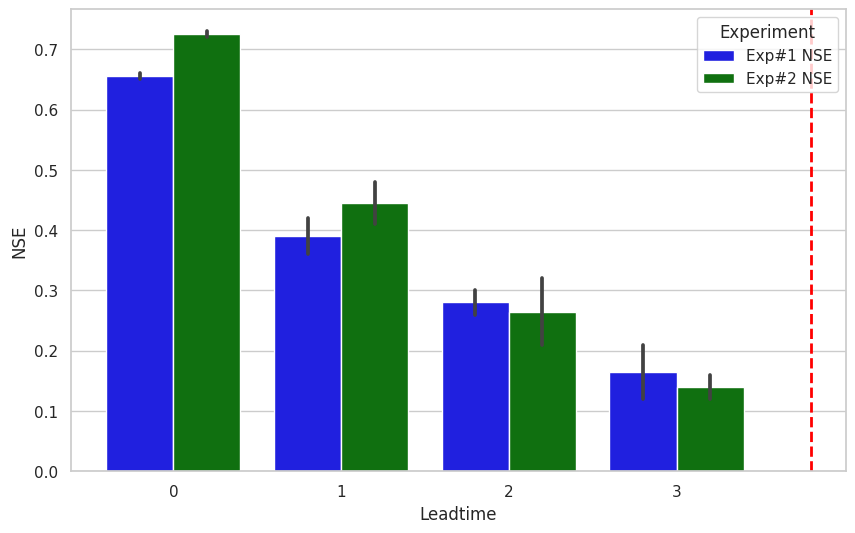

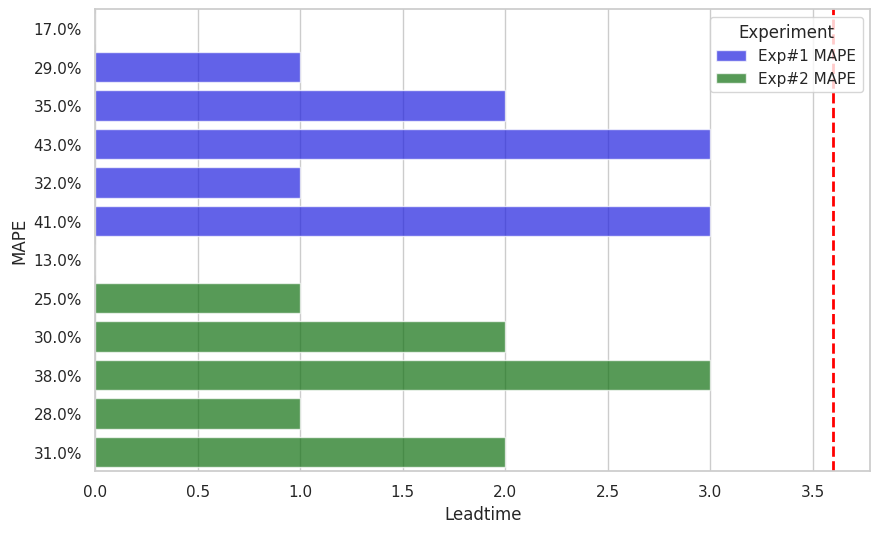

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

# Sample data (replace this with your own dataset)
leadtime = df['Leadtime']
mape_exp1 = df['MAPE']
nse_exp1 = df['NSE']
mape_exp2 = df['MAPE.1']
nse_exp2 = df['NSE.1']

# Set the width of the bars
bar_width = 0.2

# Create an array to shift the bars for side-by-side placement
bar_shift = np.arange(len(leadtime))

# Create a DataFrame for better handling with Seaborn
data_nse = pd.DataFrame({'Leadtime': leadtime, 'Exp#1 NSE': nse_exp1, 'Exp#2 NSE': nse_exp2})
data_mape = pd.DataFrame({'Leadtime': leadtime, 'Exp#1 MAPE': mape_exp1, 'Exp#2 MAPE': mape_exp2})

# Set the Seaborn style
sns.set(style="whitegrid")

# Plot the NSE values on the left
fig, axs = plt.subplots(figsize=(10, 6))
sns.barplot(x='Leadtime', y='value', hue='variable', data=pd.melt(data_nse, id_vars='Leadtime'),
            palette=["blue", "green"], ax=axs)

# Add a vertical broken line between leadtime 0 and 3
axs.axvline(3.8, color='red', linestyle='--', linewidth=2)

# Set the x-axis and y-axis labels
axs.set_xlabel('Leadtime')
axs.set_ylabel('NSE')

# Add a legend
axs.legend(title='Experiment', loc='upper right')

# Plot the MAPE values on the right
fig, axs = plt.subplots(figsize=(10, 6))
sns.barplot(x='Leadtime', y='value', hue='variable', data=pd.melt(data_mape, id_vars='Leadtime'),
            palette=["blue", "green"], ax=axs,ci=None, alpha=0.7, dodge=False)

# Add a vertical broken line between leadtime 0 and 3
axs.axvline(3.6, color='red', linestyle='--', linewidth=2)

# Set the x-axis and y-axis labels
axs.set_xlabel('Leadtime')
axs.set_ylabel('MAPE')

# Add a legend
axs.legend(title='Experiment', loc='upper right')

# Show the plots
plt.show()


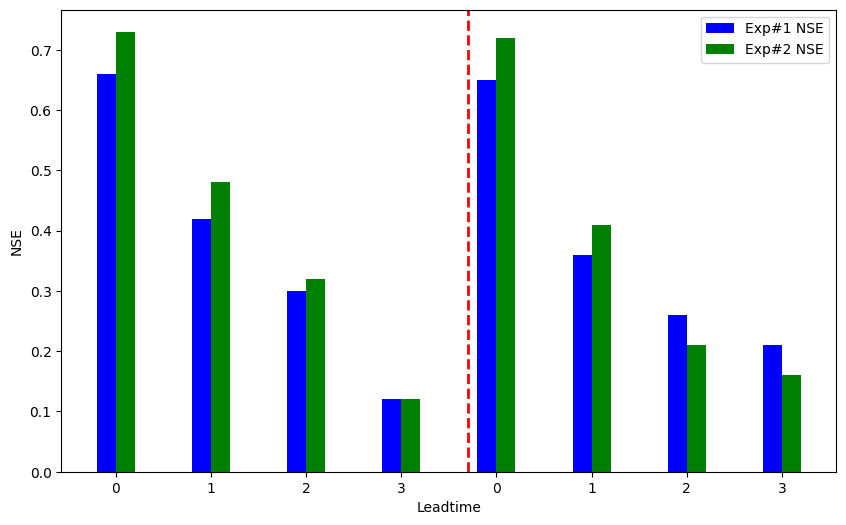

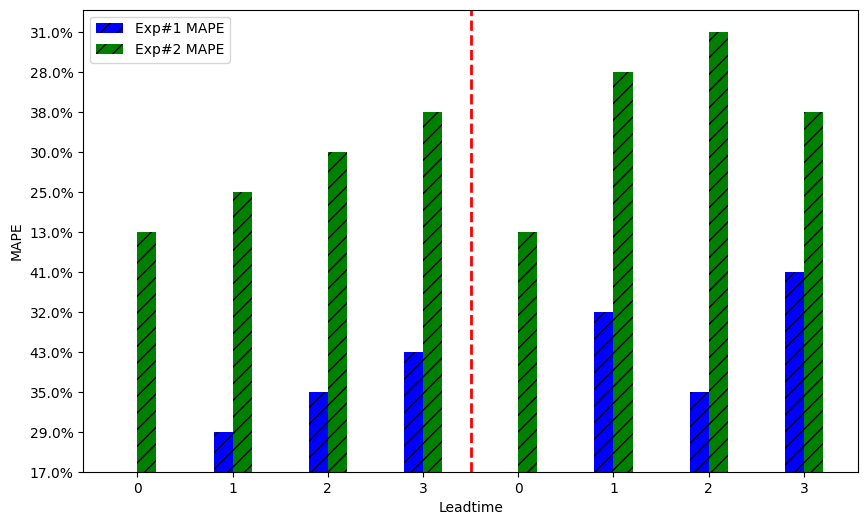

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract the relevant data from the dataframe
leadtime = df['Leadtime']
mape_exp1 = df['MAPE']
nse_exp1 = df['NSE']
mape_exp2 = df['MAPE.1']
nse_exp2 = df['NSE.1']

# Set the width of the bars
bar_width = 0.2

# Create an array to shift the bars for side-by-side placement
bar_shift = np.arange(len(leadtime))

# Plot the NSE values on the left
fig, axs = plt.subplots(figsize=(10, 6))
axs.bar(bar_shift, nse_exp1, width=bar_width, label='Exp#1 NSE', color='b', align='center')
axs.bar(bar_shift + bar_width, nse_exp2, width=bar_width, label='Exp#2 NSE', color='g', align='center')

# Add a vertical broken line between leadtime 0 and 3
axs.axvline(3.8, color='red', linestyle='--', linewidth=2)

# Set the x-axis and y-axis labels
axs.set_xlabel('Leadtime')
axs.set_ylabel('NSE')

# Set the x-axis ticks and labels
axs.set_xticks(bar_shift + bar_width / 2)
axs.set_xticklabels(leadtime)

# Add a legend
axs.legend()

# Plot the MAPE values on the right
fig, axs = plt.subplots(figsize=(10, 6))
axs.bar(bar_shift, mape_exp1, width=bar_width, label='Exp#1 MAPE', color='b', align='center',hatch ='//')
axs.bar(bar_shift + bar_width, mape_exp2, width=bar_width, label='Exp#2 MAPE', color='g', align='center',hatch ='//')

# Add a vertical broken line between leadtime 0 and 3
axs.axvline(3.6, color='red', linestyle='--', linewidth=2)

# Set the x-axis and y-axis labels
axs.set_xlabel('Leadtime')
axs.set_ylabel('MAPE')

# Set the x-axis ticks and labels
axs.set_xticks(bar_shift + bar_width / 2)
axs.set_xticklabels(leadtime)

# Add a legend
axs.legend()

# Show the plots
plt.show()


In [ ]:
# Splitting the data based on window size
df_ws30 = df[df['ws'] == 30].iloc[:7]
df_ws365 = df[df['ws'] == 365].iloc[:7]

In [ ]:
df_ws365

In [ ]:


# Splitting the data based on window size
df_ws30 = df[df['ws'] == 30].iloc[:7]
df_ws365 = df[df['ws'] == 365].iloc[7:]

# Calculate percentage error for NSE and MAPE
df_ws30['NSE_Error'] = (1 - df_ws30['Exp#1_NSE']) * 100
df_ws30['MAPE_Error'] = df_ws30['Exp#1_MAPE'] * 100
df_ws365['NSE_Error'] = (1 - df_ws365['Exp#1_NSE']) * 100
df_ws365['MAPE_Error'] = df_ws365['Exp#1_MAPE'] * 100

# Plotting the bar chart
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plotting NSE values
axs[0].bar(df_ws30['leadtime'], df_ws30['Exp#1_NSE'], yerr=df_ws30['NSE_Error'], capsize=5, width=0.4, label='Window Size 30', align='edge', color='b')
axs[0].bar(df_ws365['leadtime'], df_ws365['Exp#1_NSE'], yerr=df_ws365['NSE_Error'], capsize=5, width=0.4, label='Window Size 365', align='edge', color='g')
axs[0].set_xticks(df_ws30['leadtime'])
axs[0].set_xlabel('Lead Time')
axs[0].set_ylabel('NSE Values')
axs[0].set_title('NSE for Lead Time vs. NSE for Window Sizes')
axs[0].legend()

# Plotting MAPE values
axs[1].bar(df_ws30['leadtime'], df_ws30['Exp#1_MAPE'], yerr=df_ws30['MAPE_Error'], capsize=5, width=0.4, label='Window Size 30', align='edge', color='b')
axs[1].bar(df_ws365['leadtime'], df_ws365['Exp#1_MAPE'], yerr=df_ws365['MAPE_Error'], capsize=5, width=0.4, label='Window Size 365', align='edge', color='g')
axs[1].set_xticks(df_ws30['leadtime'])
axs[1].set_xlabel('Lead Time')
axs[1].set_ylabel('MAPE Values')
axs[1].set_title('MAPE for Lead Time vs. MAPE for Window Sizes')
axs[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Creating a subset of the dataframe with the specified index range
df_subset = df.loc[1:7]

# Creating separate plots for each metric
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(8, 12))

# Plotting 'R2'
axs[0].plot(df_subset['leadtime'], df_subset['R2'], marker='o', color='blue')
axs[0].set_ylabel('R2')

# Plotting 'MAPE'
axs[1].plot(df_subset['leadtime'], df_subset['MAPE'], marker='o', color='green')
axs[1].set_ylabel('MAPE')

# Plotting 'NSE'
axs[2].plot(df_subset['leadtime'], df_subset['NSE'], marker='o', color='red')
axs[2].set_xlabel('leadtime')
axs[2].set_ylabel('NSE')

# Adding title to the overall figure
plt.suptitle('leadtime vs R2, MAPE, NSE')

# Adjusting the spacing between subplots
plt.tight_layout()

# Showing the plot
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Creating a subset of the dataframe with relevant columns and rows
df_subset = df.iloc[2:].copy()
df_subset.columns = df_subset.iloc[0]
df_subset = df_subset[1:]
df_subset = df_subset.astype({'Leadtime': int})

# Creating separate plots for each metric
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(8, 12))

# Plotting 'R2'
axs[0].plot(df_subset['Leadtime'], df_subset['R2'], marker='o', color='blue')
axs[0].set_ylabel('R2')

# Plotting 'MAPE'
axs[1].plot(df_subset['Leadtime'], df_subset['MAPE'], marker='o', color='green')
axs[1].set_ylabel('MAPE')

# Plotting 'NSE'
axs[2].plot(df_subset['Leadtime'], df_subset['NSE'], marker='o', color='red')
axs[2].set_xlabel('Leadtime')
axs[2].set_ylabel('NSE')

# Adding title to the overall figure
plt.suptitle('Leadtime vs R2, MAPE, NSE')

# Adjusting the spacing between subplots
plt.tight_layout()

# Showing the plot
plt.show()


In [ ]:
# Line plot
plt.figure(figsize=(10, 6))
plt.plot(df['Leadtime'], df['R2'])
plt.title('Line Plot')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [ ]:
# Box plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='x_column', y='y_column')
plt.title('Box Plot')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [ ]:
# Bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='x_column', y='y_column')
plt.title('Bar Chart')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the selected rows from the Excel file
df = pd.read_excel('/content/drive/MyDrive/R_datasets/prediction_hsitavg.xlsx', sheet_name='df', nrows=100)
# Fill NaN values with 0
df = df.fillna(0)
# df = df[df['Date'].between(pd.Timestamp('2015-04-07'), pd.Timestamp('2018-12-31'))].reset_index(drop=True)
df.head(2)

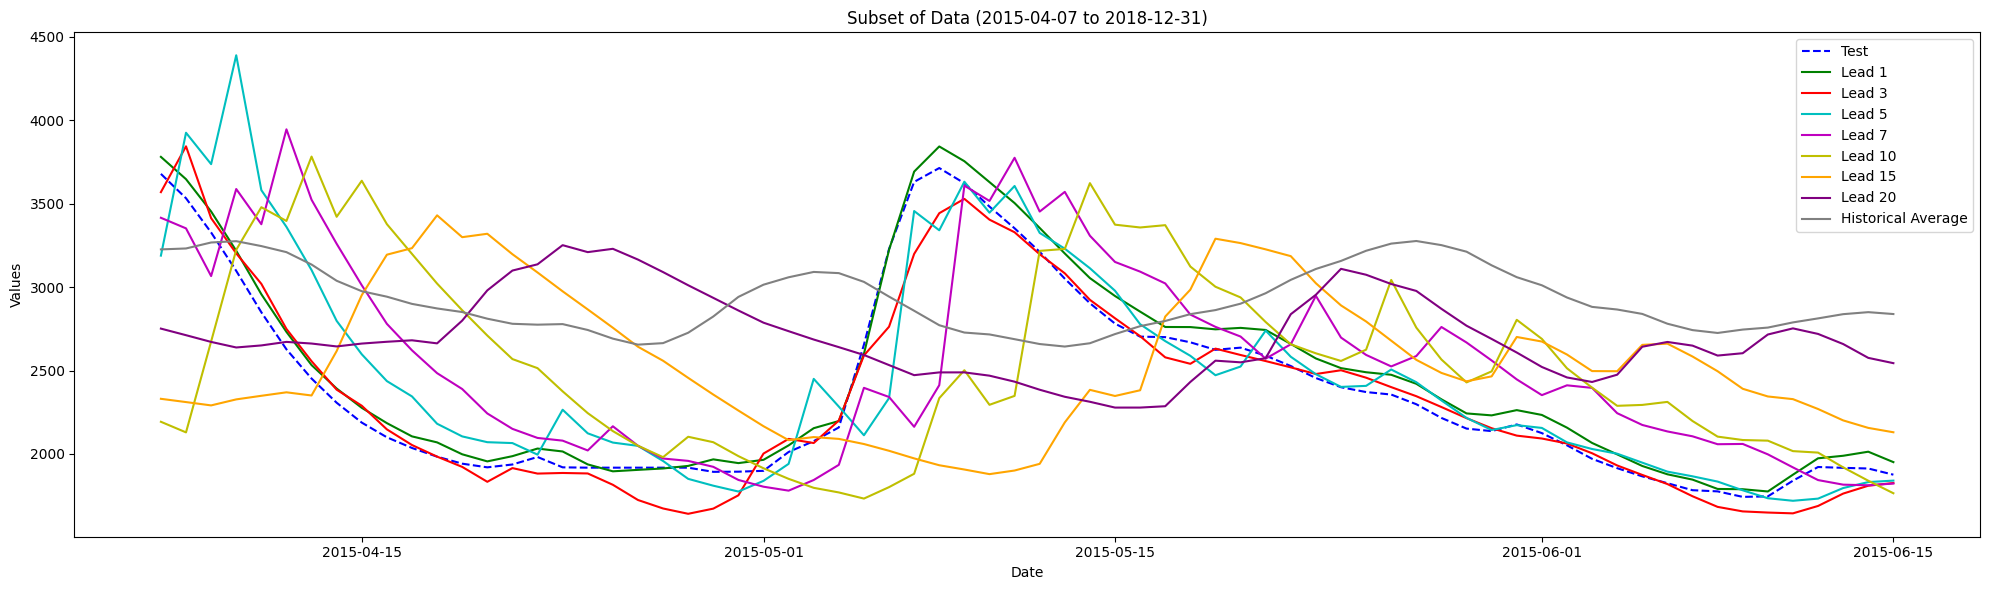

NSE: -0.9516931947722589
MAPE: 33.90128194140163


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame with columns: Date, test, lead_1, lead_3, lead_5, lead_7, lead_10, lead_15, lead_20, lead_30, hist_avg

# Convert the 'Date' column to datetime if it's not already in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Sort the DataFrame by the 'Date' column (in case it's not already sorted)
df.sort_values(by='Date', inplace=True)

# Filter the DataFrame to include only the date range between '2015-04-07' and '2018-12-31'
start_date = '2015-04-07'
end_date = '2018-12-31'
df_subset = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)]

# Plotting multiple lines for the columns 'test', 'lead_1', 'lead_3', 'lead_5', 'lead_7', 'lead_10', 'lead_15', 'lead_20', 'lead_30', and 'hist_avg' within the subset
plt.figure(figsize=(20, 6))
plt.plot(df_subset['Date'], df_subset['test'],linestyle='--', color='b', label='Test')
plt.plot(df_subset['Date'], df_subset['lead_1'],linestyle='-', color='g', label='Lead 1')
plt.plot(df_subset['Date'], df_subset['lead_3'],linestyle='-', color='r', label='Lead 3')
plt.plot(df_subset['Date'], df_subset['lead_5'],linestyle='-', color='c', label='Lead 5')
plt.plot(df_subset['Date'], df_subset['lead_7'], linestyle='-', color='m', label='Lead 7')
plt.plot(df_subset['Date'], df_subset['lead_10'],linestyle='-', color='y', label='Lead 10')
plt.plot(df_subset['Date'], df_subset['lead_15'], linestyle='-', color='orange', label='Lead 15')
plt.plot(df_subset['Date'], df_subset['lead_20'], linestyle='-', color='purple', label='Lead 20')
# plt.plot(df_subset['Date'], df_subset['lead_30'], linestyle='-', color='brown', label='Lead 30')
plt.plot(df_subset['Date'], df_subset['hist_avg'], linestyle='-', color='gray', label='Historical Average')

plt.xlabel('Date')
plt.ylabel('Values')
plt.title('Subset of Data (2015-04-07 to 2018-12-31)')
# plt.grid(True)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()
# Calculate NSE
mse = ((df_subset['test'] - df_subset['hist_avg']) ** 2).mean()
mean_test = df_subset['test'].mean()
sse = ((df_subset['test'] - mean_test) ** 2).mean()
nse = 1 - (mse / sse)

# Calculate MAPE
mape = (abs(df_subset['test'] - df_subset['hist_avg']) / df_subset['test']).mean() * 100

print("NSE:", nse)
print("MAPE:", mape)

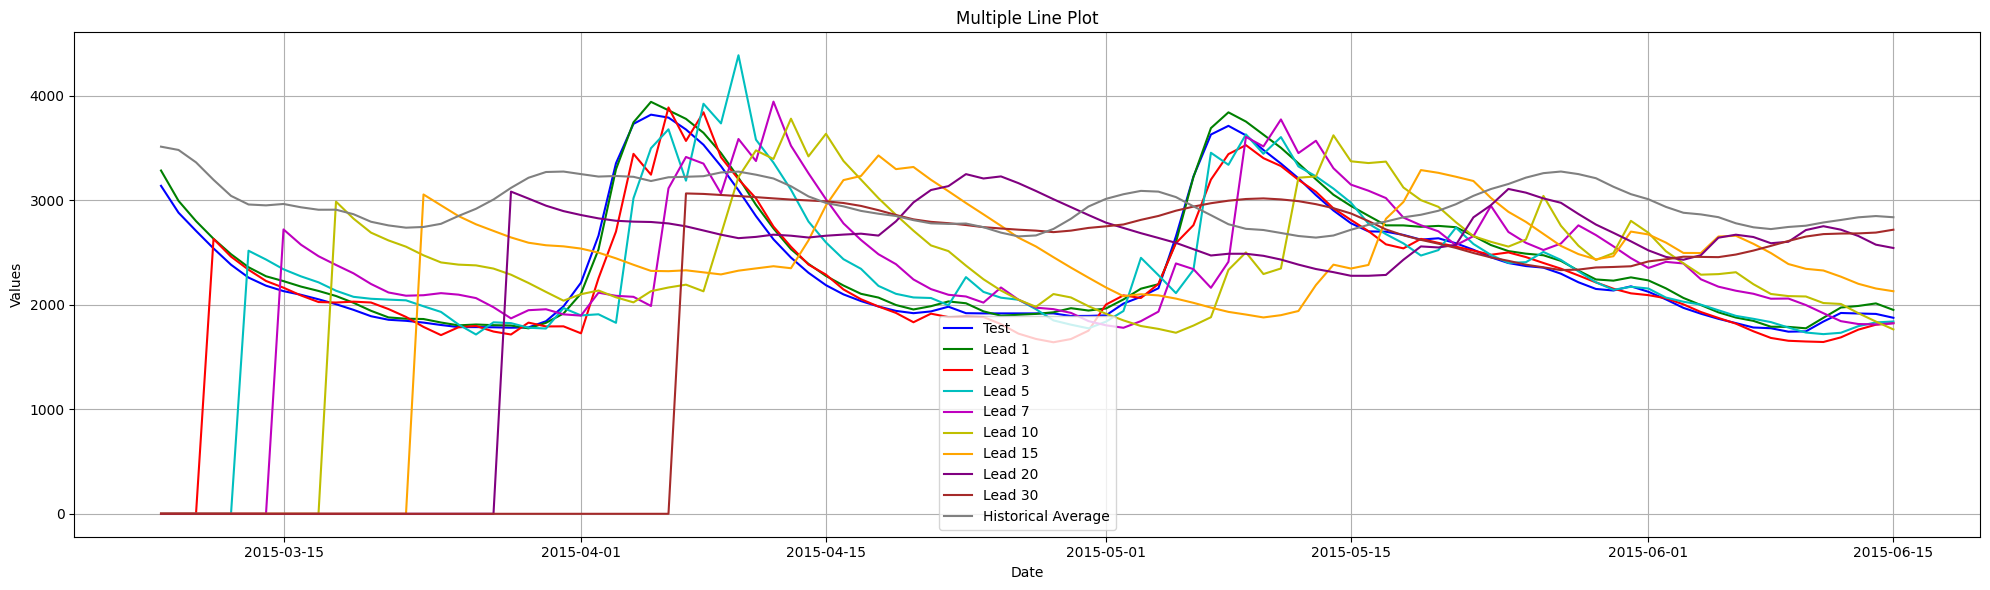

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame with columns: Date, test, lead_1, lead_3, lead_5, lead_7, lead_10, lead_15, lead_20, lead_30, hist_avg

# Convert the 'Date' column to datetime if it's not already in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Sort the DataFrame by the 'Date' column (in case it's not already sorted)
df.sort_values(by='Date', inplace=True)

# Plotting multiple lines for the columns 'test', 'lead_1', 'lead_3', 'lead_5', 'lead_7', 'lead_10', 'lead_15', 'lead_20', 'lead_30', and 'hist_avg'
plt.figure(figsize=(20, 6))
plt.plot(df['Date'], df['test'], linestyle='-', color='b', label='Test')
plt.plot(df['Date'], df['lead_1'], linestyle='-', color='g', label='Lead 1')
plt.plot(df['Date'], df['lead_3'], linestyle='-', color='r', label='Lead 3')
plt.plot(df['Date'], df['lead_5'], linestyle='-', color='c', label='Lead 5')
plt.plot(df['Date'], df['lead_7'], linestyle='-', color='m', label='Lead 7')
plt.plot(df['Date'], df['lead_10'], linestyle='-', color='y', label='Lead 10')
plt.plot(df['Date'], df['lead_15'], linestyle='-', color='orange', label='Lead 15')
plt.plot(df['Date'], df['lead_20'], linestyle='-', color='purple', label='Lead 20')
plt.plot(df['Date'], df['lead_30'], linestyle='-', color='brown', label='Lead 30')
plt.plot(df['Date'], df['hist_avg'], linestyle='-', color='gray', label='Historical Average')

plt.xlabel('Date')
plt.ylabel('Values')
plt.title('Multiple Line Plot')
plt.grid(True)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame with columns: Date, test, lead_1, lead_3, lead_5, lead_7, lead_10, lead_15, lead_20, lead_30, hist_avg
# Convert the 'Date' column to datetime if it's not already in datetime format
df['Date'] = pd.to_datetime(df['Date'])
# Plotting the 'test' column against 'Date'
plt.figure(figsize=(20, 10))
plt.plot(df['Date'], df['test'], linestyle='-', color='b')
plt.plot(df['Date'], df['hist_avg'], linestyle='-', color='r')
plt.plot(df['Date'], df['lead_1'], linestyle='-', color='y')
# plt.plot(df['Date'], df['lead_7'], linestyle='-', color='r')
plt.plot(df['Date'], df['lead_10'], linestyle='-', color='g')
plt.xlabel('Year')
plt.ylabel('Discharge(m3/s)')
plt.title('Comparsion of Baseline model  with Actual flow')
plt.legend()
# plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
# Calculate NSE
mse = ((df['test'] - df['hist_avg']) ** 2).mean()
mean_test = df['test'].mean()
sse = ((df['test'] - mean_test) ** 2).mean()
nse = 1 - (mse / sse)

# Calculate MAPE
mape = (abs(df['test'] - df['hist_avg']) / df['test']).mean() * 100

print("NSE:", nse)
print("MAPE:", mape)

In [ ]:
from keras.models import Sequential, Model
from keras.layers import LSTM, Dense
from keras.utils import plot_model
import pydot
import graphviz

In [ ]:
window_size =365
n_steps_out =1

In [ ]:
input_layer = tf.keras.layers.Input(shape=(window_size, 1))
lstm1 = LSTM(64, activation='relu', return_sequences=True)(input_layer)
lstm2 = LSTM(50, activation='relu', return_sequences=False)(lstm1)
output_layer = Dense(n_steps_out, activation='linear')(lstm2)

model = Model(inputs=input_layer, outputs=output_layer)

In [ ]:
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])


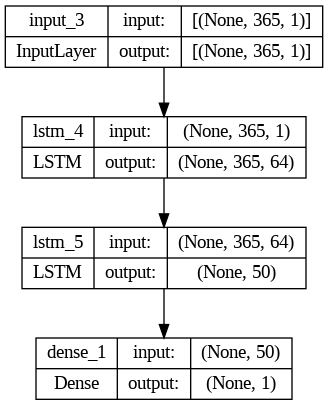

In [ ]:
plot_model(model, to_file='lstm_model.png', show_shapes=True, show_layer_names=True)

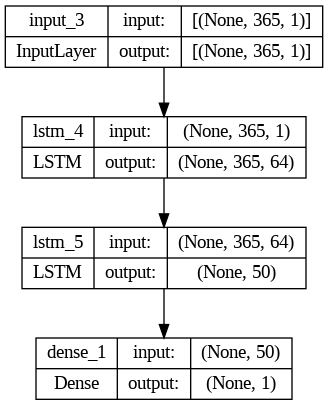

In [ ]:
from IPython.display import Image
Image(filename='lstm_model.png')
